# Identifying biological processes of DRVI factors

Factors that do not map cleanly to a single cell type often capture **biological processes**
(interferon response, cell cycle, stress, ...). This notebook annotates them with three
complementary, non-LLM enrichment tools that all consume DRVI's per-gene interpretability
scores:

| Tool | Method | Input | Strengths |
|------|--------|-------|-----------|
| **Enrichr** (via GSEApy) | Over-representation (ORA)     | Top-N gene list      | Fast; huge library collection |
| **g:Profiler**           | Over-representation (ORA)     | Ordered gene query   | g:SCS correction for hierarchical GO terms |
| **decoupler**            | Activity inference (ULM/MLM)  | Gene-score matrix + prior network | Reports *regulators* (TFs), not just terms |

It closes with a **factor-curation** helper that pulls every tool's stored output (including the
cell-type and LLM notebooks, if you ran them) into one per-factor view, and an **appendix** of
databases you can swap in.

> This is one of three companion notebooks. See
> [cell types from annotations](./identification_of_factors_1_cell_types.html) and
> [LLM-based tools](./identification_of_factors_3_llm_tools.html). They share `embed.h5ad`, so
> run the cell-type notebook first — the curation view below then shows both.

> **A note on pre-ranked GSEA.** GSEA-style methods expect signed, two-sided rankings (top =
> up, bottom = down). DRVI interpretability scores are non-negative by construction (each
> factor-direction has its own positive ranking), so there is no meaningful "bottom" for GSEA
> to exploit. In practice pre-ranked GSEA returned very few, no-more-informative hits here, so
> we restrict this notebook to ORA (Enrichr, g:Profiler) plus TF-activity inference (decoupler).

**All results are guiding — interpret in context and validate against known biology.**

## Prerequisites

Assumes a trained DRVI model with interpretability scores (see the
[general pipeline](./general_pipeline.html)).

**Adapting to your own model** — change `io_dir` (Section 0) and, per tool, the database/organism
config: `gseapy_db` (2.1), `organism` + `gp_source` (2.2), `dc_geneset` + `dc_organism` (2.3).
See the [appendix](#5.-Appendix:-database-reference) for options.

## Contact

Questions: [scverse discourse](https://discourse.scverse.org/). Bugs:
[issue tracker](https://github.com/theislab/drvi/issues).

## Install

On Colab, the next cell installs the dependencies. Remove it if your environment is ready.

In [1]:
import sys
import subprocess

branch = "latest"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and branch == "stable":
    subprocess.check_call([sys.executable, "-m", "pip", "install", "drvi-py[tutorials]"])
elif IN_COLAB and branch != "stable":
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "git+https://github.com/theislab/drvi.git#egg=drvi-py[tutorials]"])

if IN_COLAB:
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "gseapy", "gprofiler-official", "decoupler"])

## Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

import scvi
import drvi
from drvi.model import DRVI

In [4]:
print("Last run with scvi-tools version:", scvi.__version__)
print("Last run with DRVI version:", drvi.__version__)

Last run with scvi-tools version: 1.4.3
Last run with DRVI version: 0.2.6


In [5]:
sc.set_figure_params(dpi=100, frameon=False, figsize=(3, 3))
plt.rcParams["figure.dpi"] = 100

## 0. Setup

### Config

In [6]:
# Input/output directory holding the trained model and embeddings. Update accordingly.
io_dir = Path("./tmp_io/drvi_immune_128/").resolve()
print(f"Using directory: {io_dir}")

# DRVI provides two per-gene scoring approaches (both precomputed by the general pipeline):
#   "OOD_combined"            — decoder-based, favors specific genes (best for identity/top genes)
#   "IND_linear_weighted_mean"— per-cell mean effect, keeps broadly shared genes
# This is the shared scoring choice for every tool below.
score_key = "OOD_combined"

Using directory: /Users/amir/projects/drvi_tutorials/tmp_io/drvi_immune_128


### Load model and embeddings

In [7]:
adata = sc.read_h5ad(io_dir / "adata_preprocesses.h5ad")
model = DRVI.load(io_dir / "drvi_model", adata)

embed_path = io_dir / "embed.h5ad"
embed = sc.read_h5ad(embed_path)

# Gene x factor-direction score matrix used by all three tools.
scores_df = model.get_interpretability_scores(embed, adata, key=score_key)
gene_background = adata.var_names.tolist()

scores_df.iloc[:3, :3]

INFO     File /Users/amir/projects/drvi_tutorials/tmp_io/drvi_immune_128/drvi_model/model.pt already downloaded    


INFO     DRVI: The model is trained with DRVI version 0.2.5.                                                       


INFO     DRVI: Updaging data setup config ...                                                                      


INFO     DRVI: Done updating data source registry. Loading in DRVI version 0.2.6.                                  


INFO     DRVI: Loading model from DRVI version 0.2.5.                                                              


INFO     DRVI: Done updating model args. Loading in 0.2.6.                                                         


INFO     DRVI: The model has been initialized                                                                      


title,DR 1+,DR 1-,DR 2+
index,,,
TCL1A,0.0,0.009216,5.813187e-11
IGLL5,0.0,0.001222,0.000000e+00
PTGDS,0.0,0.001911,1.868557e-08


### Shared helper

Every tool starts from the same operation: for a factor-direction, take the top genes above a
score cutoff.

In [8]:
def top_genes(scores_df, col, cutoff, top_n):
    """Genes for a factor-direction with score >= cutoff, at most `top_n`, ranked descending."""
    s = scores_df[col]
    return s[s >= cutoff].nlargest(top_n).index.astype(str).tolist()

## 2.1 Enrichr (via GSEApy)

[GSEApy](https://github.com/zqfang/GSEApy)'s Enrichr ORA tests whether a factor's top-N gene
list is enriched for terms in a chosen library, against a gene background.

In [9]:
import gseapy

### Config

In [10]:
gseapy_db = "GO_Biological_Process_2023"   # any Enrichr library (see appendix)
gseapy_cutoff = 0.1                         # ~0.1 for OOD, ~0.5 for IND
gseapy_top_n = 100
padj_threshold = 0.05                       # adjusted p-value

### Run enrichment

In [11]:
def run_gseapy_enrichr(scores_df, gene_sets, cutoff, top_n, padj_cutoff, background):
    rows = []
    for col in scores_df.columns:
        genes = top_genes(scores_df, col, cutoff, top_n)
        if not genes:
            continue
        try:
            enr = gseapy.enrich(gene_list=genes, gene_sets=gene_sets, background=background,
                                no_plot=True, outdir=None)
        except Exception as e:
            print(f"ORA failed for {col}: {e}")
            continue
        hits = enr.results[enr.results["Adjusted P-value"] < padj_cutoff].sort_values("Adjusted P-value")
        rows.append(hits.assign(factor=col))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


gseapy_enrichr_results = run_gseapy_enrichr(
    scores_df, gseapy_db, gseapy_cutoff, gseapy_top_n, padj_threshold, gene_background
)
display(gseapy_enrichr_results.head())

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes,factor
0,GO_Biological_Process_2023,T Cell Activation (GO:0042110),4.001337e-07,0.000340,0,0,8.500000,125.217470,DPP4;CD2;ITK;LCK;CD7;CD28;RHOH;CCR7;CD3G;CD247...,DR 1-
1,GO_Biological_Process_2023,T Cell Receptor Signaling Pathway (GO:0050852),4.027758e-06,0.001710,0,0,8.333333,103.519172,ITK;LCK;TXK;THEMIS;CD28;CD3G;CD247;CD3E;CD3D;S...,DR 1-
2,GO_Biological_Process_2023,Gamma-Delta T Cell Activation (GO:0046629),2.836112e-05,0.008026,0,0,79.125000,828.477629,ITK;TCF7;CD3G;CD3E,DR 1-
3,GO_Biological_Process_2023,Antigen Receptor-Mediated Signaling Pathway (G...,4.462457e-05,0.009472,0,0,5.337601,53.467957,ITK;PLEKHA1;LCK;TXK;CD28;THEMIS;CD3G;CD247;CD3...,DR 1-
4,GO_Biological_Process_2023,Alpha-Beta T Cell Activation (GO:0046631),1.835750e-04,0.031171,0,0,26.347222,226.662180,CD3G;CD247;CD3E;CD3D,DR 1-


### Store results

In [12]:
embed.uns["gseapy_enrichr_results"] = gseapy_enrichr_results.convert_dtypes(
    convert_integer=False, convert_floating=False
)
n_sig = gseapy_enrichr_results["factor"].nunique() if not gseapy_enrichr_results.empty else 0
print(f"Enrichr significant factor-directions: {n_sig} / {scores_df.shape[1]}")

Enrichr significant factor-directions: 40 / 111


**How to read this.** ORA works well when the factor's biology is well represented in the chosen
library: hits for a lineage-aligned factor are usually specific and internally consistent (e.g.
a B-cell factor returning Ig-mediated immune response, BCR signaling). Quality is bounded by the
database, so factors whose biology is under-represented return loosely related terms. Interpret
alongside g:Profiler below — convergent terms across the two ORA tools are better supported.

## 2.2 g:Profiler

[g:Profiler](https://biit.cs.ut.ee/gprofiler/) runs ORA with g:SCS multiple-testing correction,
designed for hierarchical GO terms. In **ordered-query** mode it walks the ranked gene list to
find the best-enriched prefix, which suits continuous factor scores better than a fixed top-N.
Treat its output as a **shortlist** rather than a single label — broad umbrella terms recur
across factors while specific child terms capture finer biology.

In [13]:
from gprofiler import GProfiler

### Config

In [14]:
organism = "hsapiens"        # e.g. "mmusculus", "drerio"
gp_source = ["GO:BP"]        # e.g. ["GO:MF"], ["REAC"], ["KEGG"], ["HP"]
gp_cutoff = 0.1              # ~0.1 for OOD, ~0.5 for IND
gp_top_n = 100               # max top genes per factor-direction
pval_threshold = 0.05

### Run enrichment

In [15]:
def run_gprofiler(scores_df, background, organism, sources, pval_threshold, cutoff, top_n):
    gp = GProfiler(return_dataframe=True)
    rows = []
    for col in scores_df.columns:
        genes = top_genes(scores_df, col, cutoff, top_n)
        if not genes:
            continue
        res = gp.profile(organism=organism, query=genes, sources=sources, ordered=True,
                         user_threshold=pval_threshold, background=background)
        if res is None or res.empty:
            continue
        rows.append(res.assign(factor=col))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


gprofiler_results = run_gprofiler(
    scores_df, gene_background, organism, gp_source, pval_threshold, gp_cutoff, gp_top_n
)
if not gprofiler_results.empty:
    gprofiler_results["parents"] = gprofiler_results["parents"].astype(str)

In [16]:
n_sig = gprofiler_results["factor"].nunique() if not gprofiler_results.empty else 0
print(f"g:Profiler significant factor-directions: {n_sig} / {scores_df.shape[1]}")
gprofiler_results.sort_values(["factor", "p_value"]).head() if not gprofiler_results.empty else gprofiler_results

g:Profiler significant factor-directions: 14 / 111


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,factor
2,GO:BP,GO:0050853,B cell receptor signaling pathway,0.001592,True,"""The series of molecular signals initiated by ...",38,30,10,1977,0.333333,0.263158,query_1,['GO:0050851'],DR 13+
3,GO:BP,GO:0002399,MHC class II protein complex assembly,0.010536,True,"""The aggregation, arrangement and bonding toge...",10,81,7,1977,0.086420,0.700000,query_1,['GO:0002396'],DR 17+
4,GO:BP,GO:0002503,peptide antigen assembly with MHC class II pro...,0.010536,True,"""The binding of a peptide to the antigen bindi...",10,81,7,1977,0.086420,0.700000,query_1,"['GO:0002399', 'GO:0002495', 'GO:0002501']",DR 17+
5,GO:BP,GO:0002715,regulation of natural killer cell mediated imm...,0.004125,True,"""Any process that modulates the frequency, rat...",24,16,7,1977,0.437500,0.291667,query_1,"['GO:0002228', 'GO:0002706', 'GO:0045088']",DR 24-
6,GO:BP,GO:0002228,natural killer cell mediated immunity,0.004492,True,"""The promotion of an immune response by natura...",36,16,8,1977,0.500000,0.222222,query_1,"['GO:0002449', 'GO:0045087']",DR 24-


### Store results

In [17]:
embed.uns["gprofiler_results"] = gprofiler_results.convert_dtypes(
    convert_integer=False, convert_floating=False
)

**How to read this.** Top hits for a factor often organize general-to-specific, and g:Profiler
can surface more mechanistic terms than top-N ORA (e.g. UPR/ERAD components on a plasma-cell
factor where Enrichr returns generic B-cell terms). Coverage is typically lower than Enrichr;
read the two together and trust convergent calls more than single-tool ones.

## 2.3 decoupler

[decoupler](https://decoupler-py.readthedocs.io/) infers the **activity of regulators** from
gene-level scores against a prior-knowledge network, rather than testing gene-set overlap.
A significant hit is a transcription factor whose targets are co-enriched in the factor's top
genes — a mechanistic layer the ORA/LLM tools cannot provide. Curated networks from
[OmniPath](https://omnipathdb.org/):

- **CollecTRI** — comprehensive TF → target regulons (recommended for TF drivers).
- **DoRothEA** — TF regulons with confidence tiers A–D (tunable stringency).
- **PROGENy** — pathway footprints (Hypoxia, EGFR, TGFb, ...); exploratory for signaling.

CollecTRI and DoRothEA are usually most informative for latent factors. Multiple methods are
run and combined via consensus for robust p-values.

In [18]:
import decoupler as dc
from statsmodels.stats.multitest import multipletests

### Config

In [19]:
dc_geneset = "collectri"        # or "dorothea", "progeny"
dc_organism = "human"           # match the data species
dc_cutoff = 0.01                # ~0.01 for OOD, ~0.05 for IND; scores below this are zeroed
fdr_threshold = 0.05

dc_methods = ["ulm", "mlm"]
dc_min = 10                     # min genes of a regulon present in the data for a valid test
dorothea_levels = ["A", "B", "C"]
fdr_method = "fdr_bh"

### Load the regulatory network

In [20]:
net_dispatch = {
    "collectri": lambda: dc.op.collectri(organism=dc_organism),
    "dorothea":  lambda: dc.op.dorothea(organism=dc_organism, levels=dorothea_levels),
    "progeny":   lambda: dc.op.progeny(organism=dc_organism),
}
net = net_dispatch.get(
    dc_geneset.strip().lower(),
    lambda: dc.op.resource(name=dc_geneset, organism=dc_organism),
)()

cols = ["source", "target"] + (["weight"] if "weight" in net.columns else [])
net = net[cols].dropna().drop_duplicates().reset_index(drop=True)
print(f"Network: {len(net)} interactions, {net['source'].nunique()} regulators")

Network: 42990 interactions, 1185 regulators


### Run

In [21]:
def run_decouple(factors_by_genes, net, methods, tmin, fdr_method):
    mat = factors_by_genes.copy()
    mat.columns = mat.columns.astype(str).str.upper()

    net_u = net.copy()
    net_u["target"] = net_u["target"].astype(str).str.upper()

    keep = mat.columns.intersection(net_u["target"].unique())
    mat = mat[keep].replace([np.inf, -np.inf], 0.0).fillna(0.0)

    res = dc.mt.decouple(data=mat, net=net_u, methods=methods, cons=False, tmin=tmin, verbose=True)
    _, pvals = dc.mt.consensus(res)

    out = pvals.stack().reset_index(name="p_value").rename(columns={"level_0": "factor", "level_1": "term"})
    out["p_adj"] = multipletests(out["p_value"].values, method=fdr_method)[1]
    return out


input_df = scores_df.copy()
input_df[input_df < dc_cutoff] = 0
decoupler_all = run_decouple(input_df.T, net, dc_methods, dc_min, fdr_method)

2026-07-08 12:37:45 | [INFO] ulm - Running ulm


2026-07-08 12:37:45 | [INFO] Extracted omics mat with 111 rows (observations) and 1120 columns (features)


2026-07-08 12:37:45 | [WARNING] 1 features of mat are empty, they will be removed


2026-07-08 12:37:45 | [WARNING] 56 observations of mat are empty, they will be removed


2026-07-08 12:37:45 | [INFO] Network adjacency matrix has 1081 unique features and 258 unique sources


...

2026-07-08 12:37:46 | [WARNING] 1 features of mat are empty, they will be removed


2026-07-08 12:37:46 | [WARNING] 56 observations of mat are empty, they will be removed


2026-07-08 12:37:46 | [INFO] Network adjacency matrix has 1081 unique features and 258 unique sources


2026-07-08 12:37:46 | [INFO] mlm - fitting 258 multivariate models of 1119 observations with 860 degrees of freedom


2026-07-08 12:37:46 | [INFO] mlm - done


In [22]:
# Keep the most significant regulator per factor-direction for a summary view.
decoupler_results = (
    decoupler_all[decoupler_all["p_adj"] < fdr_threshold]
    .sort_values("p_adj")
    .groupby("factor", as_index=False)
    .first()
)
print(f"Significant regulators for {decoupler_results['factor'].nunique()} / {scores_df.shape[1]} directions.")
display(decoupler_results.sort_values("p_adj"))

Significant regulators for 14 / 111 directions.


,factor,term,p_value,p_adj
12,DR 7-,RORC,5.441941e-20,7.722115e-16
0,DR 18-,RORC,1.077962e-15,5.098762e-12
7,DR 42+,YY1,8.776860e-16,5.098762e-12
1,DR 21-,ESR2,1.078331e-13,3.825380e-10
6,DR 38+,EBF1,4.649366e-08,1.030913e-04
9,DR 51-,NR0B2,5.085546e-08,1.030913e-04
3,DR 28-,NR1H3,6.014364e-08,1.066798e-04
10,DR 52-,BMAL1,2.103180e-07,3.316013e-04
11,DR 53+,PRDM1,6.800615e-06,9.650073e-03
4,DR 35+,RUNX2,7.498058e-06,9.672495e-03


### Store results

In [23]:
embed.uns["decoupler_results"] = decoupler_results.convert_dtypes(
    convert_integer=False, convert_floating=False
)

**How to read this.** Where decoupler reports a significant TF, it often lines up with the other
tools (e.g. EBF1 on a B-cell-precursor factor, PRDM1/Blimp-1 on a plasma-cell factor, RFXAP
alongside "MHC class II assembly"). Coverage is limited by design — many factors are not
dominated by a single TF — and some hits are not obviously related to the factor's identity, so
treat regulators as candidate drivers to cross-check, not conclusions.

## 3. Save

Persist the enrichment results so the curation view (and the other notebooks) can read them.

In [24]:
ad.settings.allow_write_nullable_strings = True
embed.write_h5ad(embed_path)
print(f"Updated embedding saved to: {embed_path}")

Updated embedding saved to: /Users/amir/projects/drvi_tutorials/tmp_io/drvi_immune_128/embed.h5ad


## 4. Factor curation

The integrative step: for each factor-direction, compare **all** tools' outputs and assign a
final label. Each tool contributes a different kind of evidence and none is sufficient alone.

This section is **standalone** — it reloads `embed` from disk and reads stored results from
`embed.uns` / `embed.var`. Tools whose notebook you did not run simply show "(not run)". A
practical sequence:

1. **Cell-type identity** — SMI (user annotations, then CellTypist) from the
   [cell-types notebook](./identification_of_factors_1_cell_types.html); LLM tools as coarse
   orientation when SMI is empty.
2. **Process** — g:Profiler + Enrichr together; convergent terms strengthen a call.
3. **Regulators** — where decoupler reports a TF, check consistency with the above.
4. **Literature** — none of these is formal validation; confirm before finalizing a label.

For each factor: `inspect(...)` prints all evidence, `plot_factor_summary(...)` shows its UMAP
pattern and top genes, `inspect_marker_gene(...)` tests a specific gene. Record decisions in
`MANUAL_LABELS`.

In [25]:
import scanpy as sc, pandas as pd, anndata as ad
import drvi
from drvi.model import DRVI
from pathlib import Path

In [26]:
io_dir = Path("./tmp_io/drvi_immune_128/").resolve()

embed_path = io_dir / "embed.h5ad"
adata = sc.read_h5ad(io_dir / "adata_preprocesses.h5ad")
embed = sc.read_h5ad(embed_path)
model = DRVI.load(io_dir / "drvi_model", adata)
scores_df = model.get_interpretability_scores(embed, adata, key="OOD_combined")

drvi_score_cutoff = 0.1
annot_col = "final_annotation"

INFO     File /Users/amir/projects/drvi_tutorials/tmp_io/drvi_immune_128/drvi_model/model.pt already downloaded    


INFO     DRVI: The model is trained with DRVI version 0.2.5.                                                       


INFO     DRVI: Updaging data setup config ...                                                                      


INFO     DRVI: Done updating data source registry. Loading in DRVI version 0.2.6.                                  


INFO     DRVI: Loading model from DRVI version 0.2.5.                                                              


INFO     DRVI: Done updating model args. Loading in 0.2.6.                                                         


INFO     DRVI: The model has been initialized                                                                      


### Config: which stored results to show

In [27]:
# Top-N terms shown per enrichment tool.
CURATION_TOP_N = {"gseapy_enrichr": 3, "gprofiler": 5, "decoupler": 1}

ENRICHMENT_TOOLS = [
    ("gseapy_enrichr", "gseapy_enrichr_results", "Term"),
    ("gprofiler",      "gprofiler_results",      "name"),
    ("decoupler",      "decoupler_results",      "term"),
]

# LLM tools — populated only if you ran the LLM notebook; otherwise shown as None.
LLM_TOOLS = [
    ("llm celltype",   "llm_direct_results", "cell_type"),
    ("llm process",    "llm_direct_results", "biological_process"),
    ("cassia general", "cassia_results",     "Predicted General Cell Type"),
    ("cassia detailed", "cassia_results",    "Predicted Detailed Cell Type"),
    ("gs2txt",         "gs2txt_results",     "description"),
]

# Cell-type SMI matches written by the cell-types notebook (matching column names).
VAR_ANNOTATIONS = [
    ("known (SMI)", "positive_direction_match_with_user_annotations",
                    "negative_direction_match_with_user_annotations"),
    ("celltypist",  "positive_direction_match_with_celltypist",
                    "negative_direction_match_with_celltypist"),
]

### Inspection helpers

In [28]:
def _var_value(embed, col, factor_title):
    if col not in embed.var.columns:
        return None
    row = embed.var.loc[embed.var["title"] == factor_title, col].dropna()
    return row.iloc[0] if not row.empty else None


def _uns_value(embed, key, col, factor, direction):
    df = embed.uns.get(key, pd.DataFrame())
    if df.empty or col not in df.columns:
        return None
    if "direction" in df.columns:
        mask = (df["factor"] == factor) & (df["direction"] == direction)
    else:
        mask = df["factor"] == f"{factor}{direction}"
    sub = df.loc[mask, col].dropna()
    return sub.iloc[0] if not sub.empty else None

In [29]:
def inspect(factor_label, embed, scores_df=scores_df, cutoff=drvi_score_cutoff):
    """Print a summary of all annotation tools for a single factor-direction."""
    factor, direction = factor_label[:-1].strip(), factor_label[-1]
    suf = "positive" if direction == "+" else "negative"
    print(f"\n{'=' * 60}\n  {factor_label}\n{'=' * 60}")

    print(f"\n- Manual -\n  {_var_value(embed, f'{suf}_direction_manual_label', factor)}")

    n_passing = (scores_df[factor_label] >= cutoff).sum()
    if n_passing == 0:
        print("\nNo genes above cutoff - uninformative direction.")
        return

    print(f"\nTop 10 genes ({n_passing} above cutoff):")
    for g, s in scores_df[factor_label].sort_values(ascending=False).head(10).items():
        print(f"  {g:<15} {s:.3f}")

    print("\n- Known / CellTypist -")
    for label, pos_col, neg_col in VAR_ANNOTATIONS:
        print(f"  {label:<18} {_var_value(embed, pos_col if direction == '+' else neg_col, factor)}")

    print("\n- LLM tools -")
    for label, key, col in LLM_TOOLS:
        print(f"  {label:<18} {_uns_value(embed, key, col, factor, direction)}")

    print("\n- Enrichment tools -")
    for label, key, term_col in ENRICHMENT_TOOLS:
        df = embed.uns.get(key, pd.DataFrame())
        if df.empty or term_col not in df.columns:
            print(f"  {label}: (not run)")
            continue
        hits = df[df["factor"] == factor_label][term_col].head(CURATION_TOP_N[label]).tolist() or ["(no hits)"]
        print(f"  {label}:\n" + "\n".join(f"    - {h}" for h in hits))

In [30]:
def plot_factor_summary(factor_label, embed, adata, scores_df, annot_col="final_annotation", n_genes=4):
    adata.obsm["X_drvi_umap"] = embed[adata.obs.index].obsm["X_umap"]
    drvi.utils.pl.plot_latent_dims_in_umap(
        embed, dim_subset=[factor_label], directional=True, additional_columns=[annot_col]
    )
    top = scores_df[factor_label].sort_values(ascending=False).index.to_list()[:n_genes]
    sc.pl.embedding(adata, "X_drvi_umap", color=top)

In [31]:
def inspect_marker_gene(gene, embed, adata, scores_df=scores_df, top_n=10):
    adata.obsm["X_drvi_umap"] = embed[adata.obs.index].obsm["X_umap"]
    sc.pl.embedding(adata, "X_drvi_umap", color=gene, cmap="viridis")
    return scores_df.loc[gene].sort_values(ascending=False).head(top_n)

### Go factor by factor


  DR 38+

- Manual -
  None

Top 10 genes (59 above cutoff):
  VPREB1          1.912
  IGLL1           1.605
  CMTM8           1.143
  TCL1A           1.050
  VPREB3          0.844
  MME             0.686
  CD79B           0.572
  FAM111B         0.441
  CD72            0.419
  STMN1           0.389

- Known / CellTypist -
  known (SMI)        CD10+ B cells
  celltypist         Large pre-B cells

- LLM tools -
  llm celltype       None
  llm process        None
  cassia general     None
  cassia detailed    None
  gs2txt             None

- Enrichment tools -
  gseapy_enrichr:
    - B Cell Receptor Signaling Pathway (GO:0050853)
  gprofiler:
    - (no hits)
  decoupler:
    - EBF1


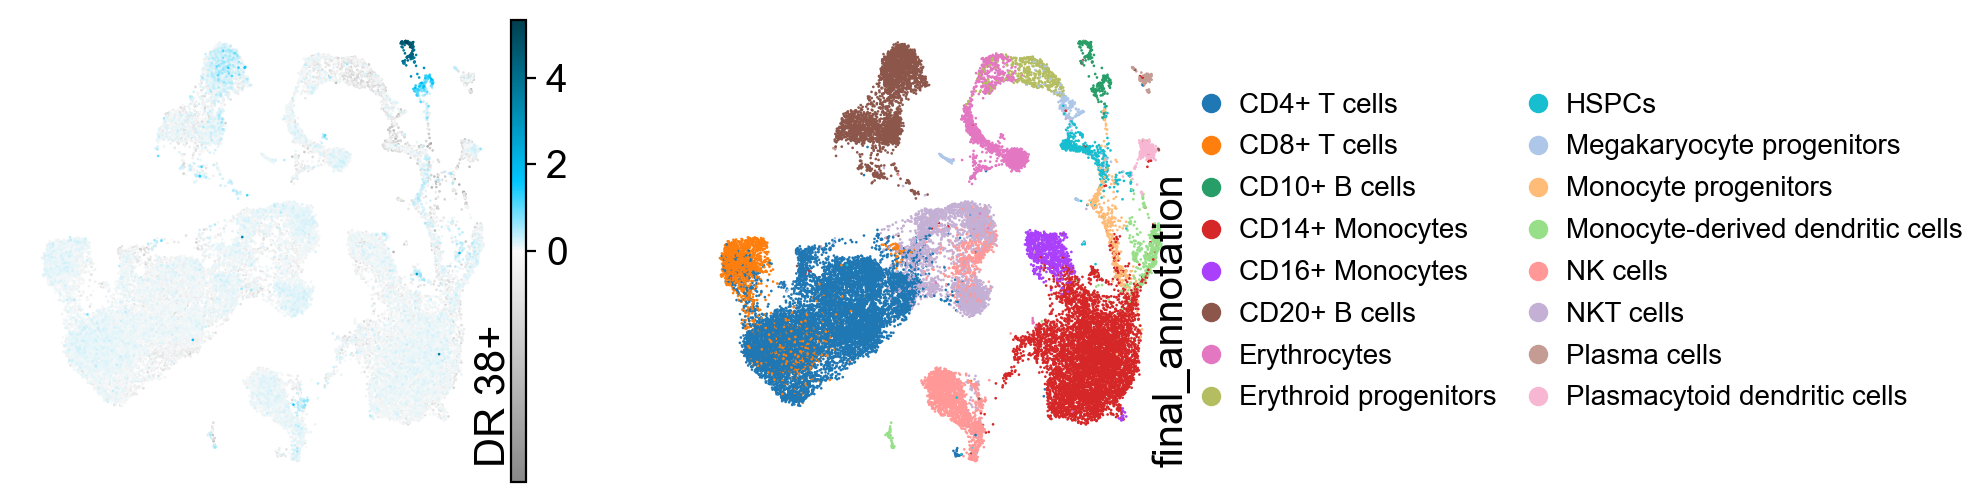

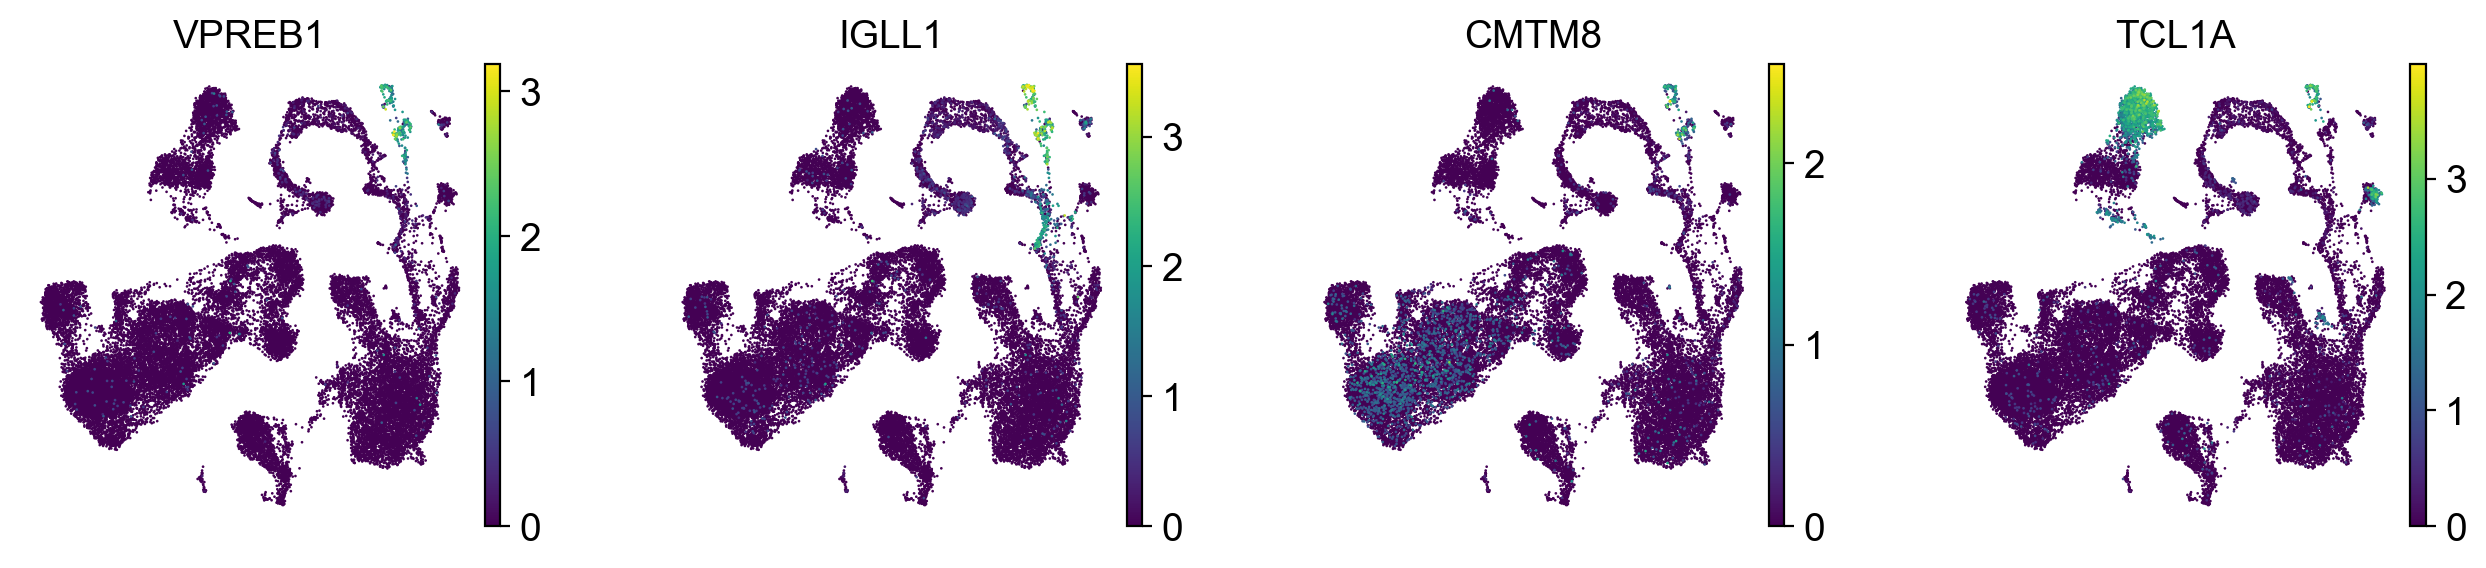

In [32]:
factor_label = "DR 38+"
inspect(factor_label, embed)
plot_factor_summary(factor_label, embed, adata, scores_df)

#### Inspect a marker gene

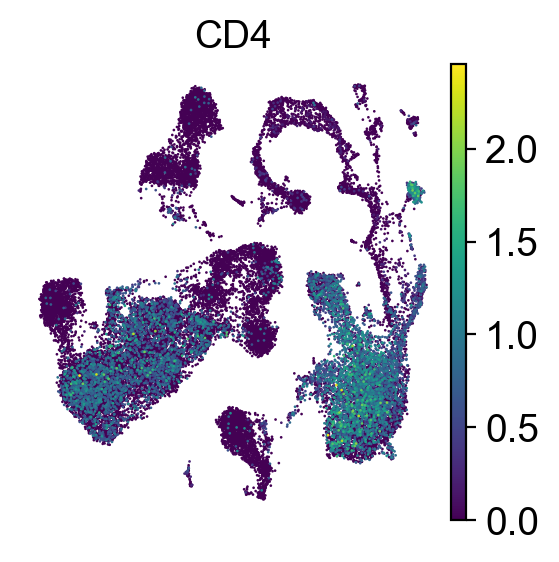

title
DR 1-     0.699452
DR 16-    0.630172
DR 6+     0.238721
DR 27-    0.187695
DR 10+    0.166661
DR 51-    0.124879
DR 2-     0.110971
DR 47-    0.106739
DR 32-    0.097778
DR 4-     0.083657
Name: CD4, dtype: float32

In [33]:
marker_gene = "CD4"
inspect_marker_gene(marker_gene, embed, adata)

### Record manual decisions

In [34]:
MANUAL_LABELS = {
    # "DR 5+": "CD8 T cell effector",
}

### Write manual labels back

In [35]:
for d, suf in [("+", "positive"), ("-", "negative")]:
    mapping = {k[:-1].strip(): v for k, v in MANUAL_LABELS.items() if k.endswith(d)}
    embed.var[f"{suf}_direction_manual_label"] = embed.var["title"].map(mapping)

ad.settings.allow_write_nullable_strings = True
embed.write_h5ad(embed_path)
print(f"Saved to: {embed_path}")

Saved to: /Users/amir/projects/drvi_tutorials/tmp_io/drvi_immune_128/embed.h5ad


## 5. Appendix: database reference

Swap the tool-specific config variables above (`gseapy_db`, `gp_source`, `dc_geneset`) to use
different databases.

### Biological process databases

| Database | Description | Enrichr library | g:Profiler |
|----------|-------------|-----------------|------------|
| MSigDB Hallmark | 50 curated, non-redundant states | `MSigDB_Hallmark_2020` | — |
| GO Biological Process | Hierarchical processes | `GO_Biological_Process_2025` | `GO:BP` |
| GO Cellular Component | Subcellular localization | `GO_Cellular_Component_2025` | `GO:CC` |
| GO Molecular Function | Molecular activities | `GO_Molecular_Function_2025` | `GO:MF` |
| Reactome | Reaction-based pathways | `Reactome_Pathways_2024` | `REAC` |
| KEGG | Metabolic/signaling maps | `KEGG_2026` | `KEGG` |
| WikiPathways | Community-curated maps | `WikiPathways_2024_Human` | `WP` |

### Cell-type marker databases (Enrichr)

| Database | Description | Enrichr library |
|----------|-------------|-----------------|
| CellMarker 2.0 | Curated markers from literature | `CellMarker_2024` |
| PanglaoDB | Curated scRNA-seq markers | `PanglaoDB_Augmented_2021` |
| Tabula Sapiens | Human single-cell atlas markers | `Tabula_Sapiens` |
| Human Gene Atlas | Tissue/cell-type expression | `Human_Gene_Atlas` |

### Regulatory networks (decoupler)

| Network | Description | decoupler name | Notes |
|---------|-------------|----------------|-------|
| CollecTRI | TF → target regulons | `collectri` | Recommended for TF drivers |
| DoRothEA | TF → target, confidence A–D | `dorothea` | Tunable stringency |
| PROGENy | Pathway-responsive signatures | `progeny` | Best for signaling activity |

### Clinical / disease phenotypes

| Database | Description | Enrichr | g:Profiler |
|----------|-------------|---------|------------|
| Human Phenotype Ontology | Genes linked to clinical signs | `Human_Phenotype_Ontology` | `HP` |
| OMIM | Human genes and genetic disorders | `OMIM_Disease` | `OMIM` |